Lecture 14: Residual Analysis

Import Libraries

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


Loading Dataset 

In [2]:
data = pd.read_csv("datasets/lecture14_insurance.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Dataset Overview

In [3]:
data.shape

(1338, 7)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Convert Categorical Values Into Numeric Values

In [6]:
data = pd.get_dummies(data,drop_first=True)

Defining Feature And Target

In [7]:
X = data.drop("charges",axis=1)
y = data["charges"]

Train/Test Split

In [8]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

Training The Model

In [10]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Prediction

In [11]:
prediction = model.predict(X_test)

Calculate Residuals

In [12]:
residual  = y_test - prediction

Residual Analysis Visualization

1. Residual Analysis

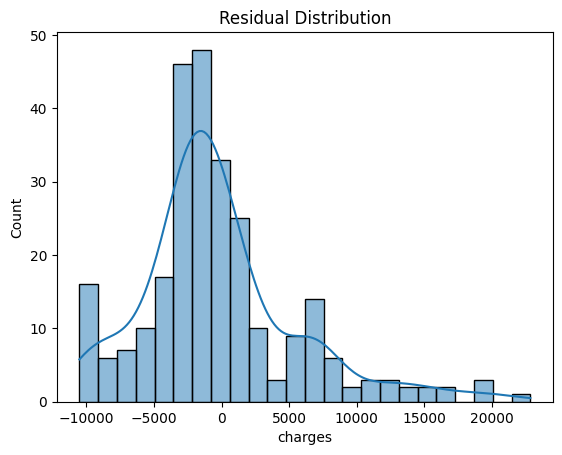

In [13]:
sns.histplot(residual, kde=True)
plt.title("Residual Distribution")
plt.show()

- Good model → roughly bell-shaped curve.

2. Residual Vs Predicted Value

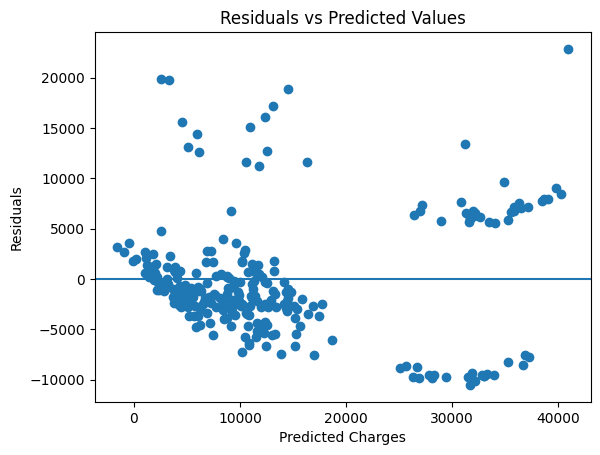

In [14]:
plt.scatter(prediction, residual)

plt.axhline(y=0)

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")

plt.title("Residuals vs Predicted Values")

plt.show()

- In good Models , Random Scatter around 0

Residual vs Features

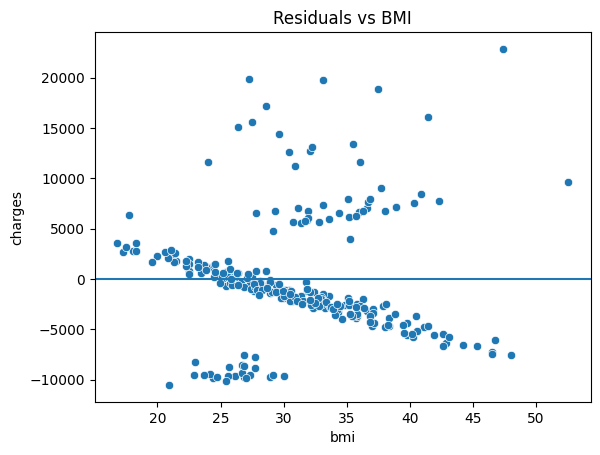

In [15]:
sns.scatterplot(x=X_test["bmi"], y=residual)

plt.axhline(y=0)

plt.title("Residuals vs BMI")

plt.show()

- used to detect model bias

4. Q-Q Plot (Normality Check)

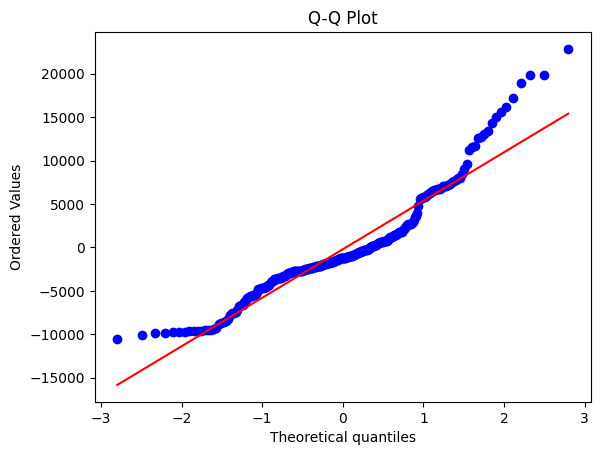

In [16]:
import scipy.stats as stats

stats.probplot(residual, dist="norm", plot=plt)

plt.title("Q-Q Plot")

plt.show()

- If points lie on a straight line, residuals are approximately normal.